In [5]:
###############################################################
#
# Automatic Explicit Water Builder
#
# Part 1
#
###############################################################

import numpy as np
import random
import matplotlib.pyplot as plt

from ase.io import read, write
from ase.build import molecule
from ase import Atoms

from ase.neighborlist import NeighborList

from scipy.spatial.transform import Rotation

from copy import deepcopy

random.seed(12345)
np.random.seed(12345)

In [42]:
###############################################################
#
# USER INPUT
#
###############################################################

POSCAR_FILE = "POSCAR"

TARGET_DENSITY = 1.00      # g/cm3

TEMPERATURE = 300.0        # K

OVERLAP_DISTANCE = 1.5     # Å

SURFACE_BUFFER = 2.5       # Å

VACUUM_TOP = 2.0           # Å

OUTPUT_POSCAR = "POSCAR_initial"

TRAJECTORY = "initial.xyz"

In [43]:
###############################################################
#
# Read Cu slab
#
###############################################################

slab = read(POSCAR_FILE)

print(slab)

print()

print("Number of atoms :", len(slab))

print("Cell")

print(slab.cell)

Atoms(symbols='Cu96', pbc=True, cell=[8.7628803253, 10.1185026169, 32.3925819397])

Number of atoms : 96
Cell
Cell([8.7628803253, 10.1185026169, 32.3925819397])


In [44]:
###############################################################
#
# Cell dimensions
#
###############################################################

cell = slab.cell.array

Lx = np.linalg.norm(cell[0])
Ly = np.linalg.norm(cell[1])
Lz = np.linalg.norm(cell[2])

print()

print("Cell lengths")

print(Lx,Ly,Lz)


Cell lengths
8.7628803253 10.1185026169 32.3925819397


In [45]:
###############################################################
#
# Surface area
#
###############################################################

A = np.linalg.norm(np.cross(cell[0],cell[1]))

print()

print("Surface area")

print(A,"Å²")


Surface area
88.66722750312957 Å²


In [46]:
###############################################################
#
# Slab thickness
#
###############################################################

positions = slab.get_positions()

z = positions[:,2]

zmin = np.min(z)

zmax = np.max(z)

slab_thickness = zmax-zmin

print()

print("Slab thickness")

print(slab_thickness)


Slab thickness
10.362644745999999


In [47]:
###############################################################
#
# Vacuum thickness
#
###############################################################

vacuum = Lz-slab_thickness

print()

print("Vacuum")

print(vacuum)


Vacuum
22.0299371937


In [48]:
###############################################################
#
# Water region
#
###############################################################

water_bottom = zmax+SURFACE_BUFFER

water_top = Lz-VACUUM_TOP

water_height = water_top-water_bottom

print()

print("Water region")

print(water_bottom)

print(water_top)

print(water_height)


Water region
12.884917061
30.3925819397
17.5076648787


In [49]:
###############################################################
#
# Water volume
#
###############################################################

volume = A*water_height

print()

print("Water volume")

print(volume)


Water volume
1552.3561048482443


In [50]:
###############################################################
#
# Water number
#
###############################################################

volume_per_water = 29.915

Nwater = int(round(volume/volume_per_water))

print()

print("Water molecules")

print(Nwater)


Water molecules
52


In [51]:
###############################################################
#
# Build SPC/E-like water molecule
#
###############################################################

def build_water():

    water = molecule("H2O")

    pos = water.get_positions()

    # Move oxygen to origin
    pos -= pos[0]

    water.set_positions(pos)

    return water


water = build_water()

print(water)
print(water.get_positions())

Atoms(symbols='OH2', pbc=False)
[[ 0.        0.        0.      ]
 [ 0.        0.763239 -0.596309]
 [ 0.       -0.763239 -0.596309]]


In [52]:
###############################################################
#
# Random orientation
#
###############################################################

def random_rotate(water):

    w = water.copy()

    R = Rotation.random()

    rot = R.as_matrix()

    pos = w.get_positions()

    pos = pos @ rot.T

    w.set_positions(pos)

    return w

In [53]:
###############################################################
#
# Random insertion point
#
###############################################################

def random_position():

    x = random.uniform(0, Lx)

    y = random.uniform(0, Ly)

    z = random.uniform(water_bottom, water_top)

    return np.array([x, y, z])

In [54]:
###############################################################
#
# Translate water
#
###############################################################

def translate_water(water, position):

    w = water.copy()

    w.translate(position)

    return w

In [55]:
###############################################################
#
# PBC-aware overlap check
#
###############################################################

def has_overlap(new_water, system):

    new_pos = new_water.get_positions()

    old_pos = system.get_positions()


    for p1 in new_pos:

        for p2 in old_pos:

            # displacement
            dr = p2-p1

            # convert to fractional coordinates
            frac = np.linalg.solve(system.cell.array.T, dr)

            # minimum image
            frac -= np.round(frac)

            # back to Cartesian
            dr = frac @ system.cell.array


            r = np.linalg.norm(dr)


            if r < OVERLAP_DISTANCE:

                return True


    return False

In [56]:
###############################################################
#
# Insert one water
#
###############################################################

#def insert_one_water(system, template):

#    attempts = 0

#    while True:

#        attempts += 1

#        water = random_rotate(template)

#        water = translate_water(water, random_position())

#        if not has_overlap(water, system):

#            system += water

#            return attempts
def insert_one_water(system, template, max_attempts=5000):

    for attempt in range(max_attempts):

        water = random_rotate(template)

        water = translate_water(
            water,
            random_position()
        )

        if not has_overlap(water, system):

            system += water

            return attempt+1


    return None

In [57]:
###############################################################
#
# Build complete solvent
#
###############################################################

#system = slab.copy()

#template = build_water()

#total_attempts = 0

#for i in range(Nwater):

#    ntry = insert_one_water(system, template)

#    total_attempts += ntry

#    if (i + 1) % 5 == 0 or i == Nwater - 1:
#        print(f"Inserted {i+1:2d}/{Nwater} waters")

#print("\nDone.")
#print(f"Total insertion attempts: {total_attempts}")
#print(f"Total atoms: {len(system)}")
system = slab.copy()

template = build_water()

total_attempts = 0

successful = 0

for i in range(Nwater):

    ntry = insert_one_water(system, template)

    if ntry is None:

        print("Could not insert water:", i+1)
        break

    successful += 1
    total_attempts += ntry

    print(
        f"Water {i+1}/{Nwater}, attempts = {ntry}"
    )


print()
print("Successfully inserted:", successful)
print("Total atoms:", len(system))

Water 1/52, attempts = 1
Water 2/52, attempts = 1
Water 3/52, attempts = 1
Water 4/52, attempts = 1
Water 5/52, attempts = 2
Water 6/52, attempts = 2
Water 7/52, attempts = 1
Water 8/52, attempts = 1
Water 9/52, attempts = 2
Water 10/52, attempts = 1
Water 11/52, attempts = 2
Water 12/52, attempts = 1
Water 13/52, attempts = 1
Water 14/52, attempts = 1
Water 15/52, attempts = 1
Water 16/52, attempts = 3
Water 17/52, attempts = 2
Water 18/52, attempts = 3
Water 19/52, attempts = 2
Water 20/52, attempts = 2
Water 21/52, attempts = 3
Water 22/52, attempts = 1
Water 23/52, attempts = 2
Water 24/52, attempts = 2
Water 25/52, attempts = 2
Water 26/52, attempts = 1
Water 27/52, attempts = 1
Water 28/52, attempts = 1
Water 29/52, attempts = 1
Water 30/52, attempts = 2
Water 31/52, attempts = 3
Water 32/52, attempts = 8
Water 33/52, attempts = 3
Water 34/52, attempts = 11
Water 35/52, attempts = 5
Water 36/52, attempts = 3
Water 37/52, attempts = 2
Water 38/52, attempts = 2
Water 39/52, attempt

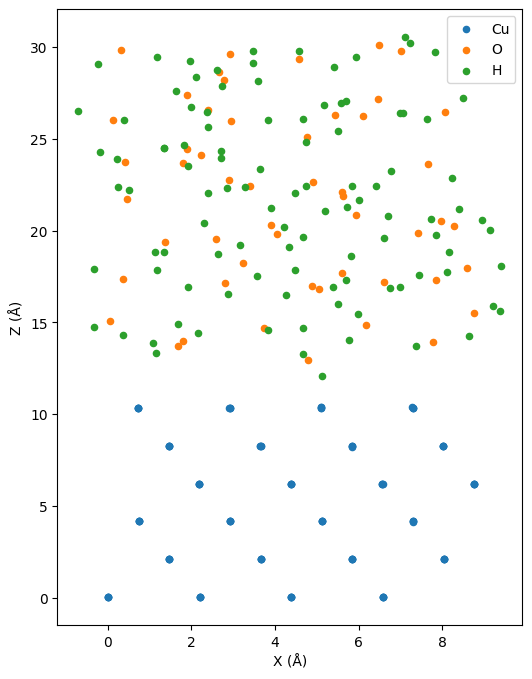

In [58]:
###############################################################
#
# Plot x-z projection
#
###############################################################

pos = system.get_positions()

sym = system.get_chemical_symbols()

plt.figure(figsize=(6,8))

for s in ["Cu", "O", "H"]:

    idx = [i for i, x in enumerate(sym) if x == s]

    plt.scatter(
        pos[idx,0],
        pos[idx,2],
        label=s,
        s=20
    )

plt.xlabel("X (Å)")
plt.ylabel("Z (Å)")
plt.legend()

plt.show()

In [59]:
###############################################################
#
# Save initial structure
#
###############################################################

write(OUTPUT_POSCAR, system, format="vasp", direct=False)

write(TRAJECTORY, system)

print("Initial structure written.")

Initial structure written.


In [60]:
###############################################################
#
# Water molecule index
#
###############################################################

nCu = len(slab)

water_indices = []

for i in range(Nwater):

    start = nCu + 3*i

    water_indices.append([start,
                          start+1,
                          start+2])

print()

print("Number of waters :",len(water_indices))

print()

print("First water :",water_indices[0])

print("Last water :",water_indices[-1])


Number of waters : 52

First water : [96, 97, 98]
Last water : [249, 250, 251]


In [61]:
###############################################################
#
# SPC/E Charges
#
###############################################################

charges = np.zeros(len(system))

for mol in water_indices:

    O,H1,H2 = mol

    charges[O]  = -0.8476

    charges[H1] = +0.4238

    charges[H2] = +0.4238

print("Charges assigned.")

Charges assigned.


In [62]:
###############################################################
#
# Atom types
#
###############################################################

symbols = np.array(system.get_chemical_symbols())

print(np.unique(symbols))

['Cu' 'H' 'O']


In [63]:
###############################################################
#
# Lennard-Jones parameters
#
###############################################################

sigma = {

("O","O"):3.166,

("Cu","O"):2.90,

("O","Cu"):2.90

}

epsilon = {

("O","O"):0.1553,

("Cu","O"):0.12,

("O","Cu"):0.12

}

In [64]:
###############################################################
#
# Lennard Jones
#
###############################################################

def LJ(r,sig,eps):

    sr = sig/r

    sr6 = sr**6

    sr12 = sr6*sr6

    return 4*eps*(sr12-sr6)

In [65]:
###############################################################
#
# Coulomb
#
###############################################################

ke = 14.3996454784255

def Coulomb(r,q1,q2):

    return ke*q1*q2/r

In [82]:
###############################################################
#
# Correct pair energy
#
###############################################################

def pair_energy(i,j):

    r = system.get_distance(i,j,mic=True)

    si = symbols[i]
    sj = symbols[j]


    E = 0.0


    ###########################################################
    # Skip intramolecular water interactions
    ###########################################################

    for mol in water_indices:

        if i in mol and j in mol:

            # keep Coulomb
            # remove LJ

            qi = charges[i]
            qj = charges[j]

            if qi != 0 and qj != 0:

                E += Coulomb(
                    r,
                    qi,
                    qj
                )

            return E



    ###########################################################
    # Lennard Jones
    ###########################################################

    key=(si,sj)

    if key in sigma:

        E += LJ(
            r,
            sigma[key],
            epsilon[key]
        )


    ###########################################################
    # Coulomb
    ###########################################################

    qi=charges[i]
    qj=charges[j]


    if qi != 0 and qj != 0:

        E += Coulomb(
            r,
            qi,
            qj
        )


    return E

In [83]:
print(pair_energy(96,99))

1.3507858018536139


In [84]:
###############################################################
#
# Local energy of one water molecule
#
###############################################################

def water_energy(mol_id):

    """
    Energy of one water molecule with
    all surrounding atoms.
    """

    atoms = water_indices[mol_id]

    E = 0.0

    natoms = len(system)

    for i in atoms:

        for j in range(natoms):

            # Skip self interactions
            if j in atoms:
                continue

            E += pair_energy(i, j)

    return 0.5 * E

In [85]:
print(water_energy(0))

-0.2712697868121784


In [86]:
###############################################################
#
# Check minimum atomic distance
#
###############################################################

from ase.geometry import get_distances

min_dist = 100

pair = None

positions = system.get_positions()

for i in range(len(system)):

    for j in range(i+1,len(system)):

        if system[i].symbol=="Cu" and system[j].symbol=="Cu":
            continue

        d = system.get_distance(i,j,mic=True)

        if d < min_dist:

            min_dist = d
            pair = (i,j,
                    system[i].symbol,
                    system[j].symbol)

print("Minimum distance:")
print(min_dist)

print("Atom pair:")
print(pair)

Minimum distance:
0.9685650182625825
Atom pair:
(231, 233, 'O', 'H')


In [87]:
###############################################################
#
# Minimum intermolecular distance
#
###############################################################

min_dist = 100
pair = None

positions = system.get_positions()


# create list of molecule IDs
mol_id = np.full(len(system), -1)

# Cu atoms
mol_id[:96] = -2


# water molecule labels
for m, inds in enumerate(water_indices):

    for i in inds:
        mol_id[i] = m


for i in range(len(system)):

    for j in range(i+1,len(system)):

        # skip atoms in same molecule
        if mol_id[i] == mol_id[j]:
            continue


        d = system.get_distance(i,j,mic=True)


        if d < min_dist:

            min_dist = d
            pair = (
                i,
                j,
                system[i].symbol,
                system[j].symbol
            )


print("Minimum intermolecular distance:")
print(min_dist)

print("Pair:")
print(pair)

Minimum intermolecular distance:
1.512828949792086
Pair:
(190, 223, 'H', 'H')


In [88]:
###############################################################
#
# Monte Carlo constants
#
###############################################################

kB = 8.617333262e-5   # eV/K

beta = 1/(kB*TEMPERATURE)

print("beta =", beta)

beta = 38.68172707248528


In [89]:
###############################################################
#
# Store water coordinates
#
###############################################################

def get_water_positions(mol_id):

    inds = water_indices[mol_id]

    return system.positions[inds].copy()



def restore_water_positions(mol_id, old_pos):

    inds = water_indices[mol_id]

    system.positions[inds] = old_pos

In [90]:
###############################################################
#
# Trial molecular move
#
###############################################################

MAX_TRANSLATION = 0.30   # Å

MAX_ROTATION = 10        # degrees



def move_water(mol_id):

    inds = water_indices[mol_id]

    coords = system.positions[inds]


    # center of mass
    center = np.mean(coords, axis=0)


    # translation

    displacement = np.random.uniform(
        -MAX_TRANSLATION,
        MAX_TRANSLATION,
        3
    )


    coords = coords - center


    # rotation

    angle = np.random.uniform(
        -MAX_ROTATION,
        MAX_ROTATION
    )


    axis = np.random.rand(3)

    axis /= np.linalg.norm(axis)


    rot = Rotation.from_rotvec(
        np.deg2rad(angle)*axis
    )


    coords = rot.apply(coords)


    coords += center + displacement


    system.positions[inds] = coords

In [91]:
###############################################################
#
# Energy difference
#
###############################################################

def trial_energy_change(mol_id):

    old = get_water_positions(mol_id)

    E_old = water_energy(mol_id)


    move_water(mol_id)


    E_new = water_energy(mol_id)


    dE = E_new-E_old


    return dE, old

In [92]:
###############################################################
#
# Accept / reject
#
###############################################################

def metropolis_step(mol_id):

    dE, old = trial_energy_change(mol_id)


    if dE <= 0:

        return True, dE


    probability = np.exp(-beta*dE)


    if random.random() < probability:

        return True, dE


    else:

        restore_water_positions(
            mol_id,
            old
        )

        return False, dE

In [93]:
accepted, dE = metropolis_step(0)

print("Accepted:",accepted)

print("Energy change:",dE)

Accepted: False
Energy change: 2.990731776176388


In [94]:
write(
"Cu111_water_initial.xyz",
system
)

In [95]:
###############################################################
#
# Total system energy (no double counting)
#
###############################################################

def total_energy():

    E = 0.0

    N = len(system)


    for i in range(N):

        for j in range(i+1, N):

            # Skip Cu-Cu interactions
            # (Cu slab is not being optimized in MC)

            if symbols[i]=="Cu" and symbols[j]=="Cu":
                continue


            E += pair_energy(i,j)


    return E

In [96]:
E0 = total_energy()

print("Initial total energy =",E0,"eV")

Initial total energy = 6862.4886253762925 eV


In [106]:
###############################################################
#
# Updated chemical overlap check for water insertion
#
###############################################################

def has_overlap(new_water, system):

    new_pos = new_water.get_positions()
    new_symbols = new_water.get_chemical_symbols()

    old_pos = system.get_positions()
    old_symbols = system.get_chemical_symbols()


    for p1,s1 in zip(new_pos,new_symbols):

        for p2,s2 in zip(old_pos,old_symbols):


            dr = p2-p1


            # Minimum image convention

            frac = np.linalg.solve(
                system.cell.array.T,
                dr
            )

            frac -= np.round(frac)

            dr = frac @ system.cell.array


            r = np.linalg.norm(dr)


            # -------------------------------
            # Water-water interactions
            # -------------------------------

            if s1=="O" and s2=="O":

                cutoff = 2.4


            elif ((s1=="O" and s2=="H") or 
                  (s1=="H" and s2=="O")):

                cutoff = 1.8


            elif s1=="H" and s2=="H":

                cutoff = 1.4


            # -------------------------------
            # Cu-water interaction
            # -------------------------------

            elif ((s1=="Cu" and s2=="O") or 
                  (s1=="O" and s2=="Cu")):

                cutoff = 2.0


            elif ((s1=="Cu" and s2=="H") or 
                  (s1=="H" and s2=="Cu")):

                cutoff = 1.6


            else:

                cutoff = 0


            if r < cutoff:

                return True


    return False

In [107]:
system = slab.copy()

In [110]:
system = slab.copy()

template = build_water()

total_attempts = 0

successful = 0

for i in range(Nwater):

    ntry = insert_one_water(system, template)

    if ntry is None:

        print("Could not insert water:", i+1)
        break

    successful += 1
    total_attempts += ntry

    print(
        f"Water {i+1}/{Nwater}, attempts = {ntry}"
    )


print()
print("Successfully inserted:", successful)
print("Total atoms:", len(system))

Water 1/52, attempts = 1
Water 2/52, attempts = 2
Water 3/52, attempts = 1
Water 4/52, attempts = 1
Water 5/52, attempts = 1
Water 6/52, attempts = 1
Water 7/52, attempts = 1
Water 8/52, attempts = 1
Water 9/52, attempts = 1
Water 10/52, attempts = 1
Water 11/52, attempts = 1
Water 12/52, attempts = 2
Water 13/52, attempts = 3
Water 14/52, attempts = 3
Water 15/52, attempts = 1
Water 16/52, attempts = 2
Water 17/52, attempts = 3
Water 18/52, attempts = 1
Water 19/52, attempts = 1
Water 20/52, attempts = 2
Water 21/52, attempts = 3
Water 22/52, attempts = 6
Water 23/52, attempts = 3
Water 24/52, attempts = 10
Water 25/52, attempts = 5
Water 26/52, attempts = 5
Water 27/52, attempts = 3
Water 28/52, attempts = 4
Water 29/52, attempts = 4
Water 30/52, attempts = 9
Water 31/52, attempts = 3
Water 32/52, attempts = 18
Water 33/52, attempts = 7
Water 34/52, attempts = 6
Water 35/52, attempts = 4
Water 36/52, attempts = 8
Water 37/52, attempts = 10
Water 38/52, attempts = 35
Water 39/52, atte

In [111]:
print(len(system))

252


In [112]:
min_OO = 100

for i in range(len(system)):

    if system[i].symbol!="O":
        continue

    for j in range(i+1,len(system)):

        if system[j].symbol!="O":
            continue

        d = system.get_distance(i,j,mic=True)

        if d < min_OO:
            min_OO=d


print("Minimum O-O distance =",min_OO)

Minimum O-O distance = 2.4117665191639612


In [113]:
print(total_energy())

-298.3306687375313


In [114]:
from ase.io import write

write(
    "Cu111_52H2O_initial.xyz",
    system
)

print("Initial structure saved")

Initial structure saved


In [115]:
###############################################################
#
# Monte Carlo equilibration
#
###############################################################

MC_STEPS = 10000


accepted_moves = 0

energy_history = []

acceptance_history = []


for step in range(MC_STEPS):


    mol_id = random.randint(
        0,
        Nwater-1
    )


    accepted, dE = metropolis_step(mol_id)


    if accepted:
        accepted_moves += 1


    if step % 100 == 0:


        E = total_energy()

        acc = accepted_moves/(step+1)


        energy_history.append(E)

        acceptance_history.append(acc)


        print(
            f"Step {step:6d} "
            f"E = {E:10.3f} eV "
            f"Acceptance = {acc:.3f}"
        )

Step      0 E =   -298.331 eV Acceptance = 0.000
Step    100 E =   -375.860 eV Acceptance = 0.436
Step    200 E =   -428.753 eV Acceptance = 0.373
Step    300 E =   -442.892 eV Acceptance = 0.336
Step    400 E =   -458.768 eV Acceptance = 0.322
Step    500 E =   -469.908 eV Acceptance = 0.313
Step    600 E =   -481.676 eV Acceptance = 0.309
Step    700 E =   -487.056 eV Acceptance = 0.300
Step    800 E =   -490.477 eV Acceptance = 0.291
Step    900 E =   -493.088 eV Acceptance = 0.287
Step   1000 E =   -495.677 eV Acceptance = 0.280
Step   1100 E =   -497.386 eV Acceptance = 0.269
Step   1200 E =   -500.562 eV Acceptance = 0.266
Step   1300 E =   -502.628 eV Acceptance = 0.257
Step   1400 E =   -505.735 eV Acceptance = 0.255
Step   1500 E =   -506.123 eV Acceptance = 0.247
Step   1600 E =   -506.546 eV Acceptance = 0.239
Step   1700 E =   -507.397 eV Acceptance = 0.233
Step   1800 E =   -508.107 eV Acceptance = 0.225
Step   1900 E =   -508.696 eV Acceptance = 0.218
Step   2000 E =   -5

In [117]:
min_OO = 100

for i in range(len(system)):

    if system[i].symbol!="O":
        continue

    for j in range(i+1,len(system)):

        if system[j].symbol!="O":
            continue

        d=system.get_distance(i,j,mic=True)

        if d < min_OO:
            min_OO=d


print("Minimum O-O distance =",min_OO)

Minimum O-O distance = 2.969519895620638


In [119]:
print("Total atoms:", len(system))

from collections import Counter

print(Counter(system.get_chemical_symbols()))

Total atoms: 252
Counter({'H': 104, 'Cu': 96, 'O': 52})


In [120]:
print("Number of water molecules:", len(water_indices))

Number of water molecules: 52


In [121]:
from ase.io import read

test = read(
    "CONTCAR_Cu111_52H2O_MC",
    format="vasp"
)

print(len(test))

from collections import Counter

print(Counter(test.get_chemical_symbols()))

252
Counter({'H': 104, 'Cu': 96, 'O': 52})


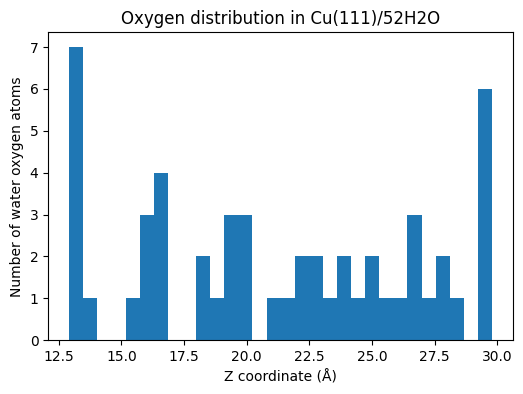

In [122]:
import matplotlib.pyplot as plt

z_water = []

for atom in system:

    if atom.symbol == "O":
        z_water.append(atom.position[2])


plt.figure(figsize=(6,4))

plt.hist(
    z_water,
    bins=30
)

plt.xlabel("Z coordinate (Å)")
plt.ylabel("Number of water oxygen atoms")

plt.title("Oxygen distribution in Cu(111)/52H2O")

plt.show()

In [123]:
from ase.io import write

new_order = (
    [atom for atom in system if atom.symbol=="Cu"] +
    [atom for atom in system if atom.symbol=="O"] +
    [atom for atom in system if atom.symbol=="H"]
)

from ase import Atoms

final_atoms = Atoms(
    new_order,
    cell=system.cell,
    pbc=True
)

write(
    "CONTCAR_Cu111_52H2O_MC_ordered",
    final_atoms,
    format="vasp",
    direct=True
)

print("Ordered CONTCAR generated")

Ordered CONTCAR generated


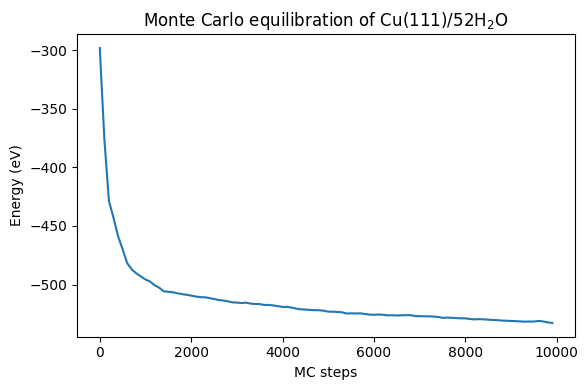

In [124]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(energy_history))*100

plt.figure(figsize=(6,4))

plt.plot(
    steps,
    energy_history
)

plt.xlabel("MC steps")
plt.ylabel("Energy (eV)")
plt.title("Monte Carlo equilibration of Cu(111)/52H$_2$O")

plt.tight_layout()
plt.show()

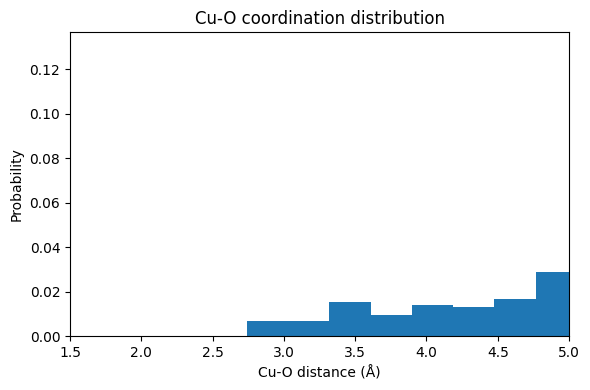

In [125]:
cu_o_dist = []

for i,atom1 in enumerate(system):

    if atom1.symbol != "Cu":
        continue

    for j,atom2 in enumerate(system):

        if atom2.symbol != "O":
            continue

        d = system.get_distance(
            i,j,
            mic=True
        )

        cu_o_dist.append(d)


plt.figure(figsize=(6,4))

plt.hist(
    cu_o_dist,
    bins=50,
    density=True
)

plt.xlabel("Cu-O distance (Å)")
plt.ylabel("Probability")

plt.title("Cu-O coordination distribution")

plt.xlim(1.5,5)

plt.tight_layout()
plt.show()